<a href="https://colab.research.google.com/github/AnnaPaulaFigueiredo/data_master/blob/main/02_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import warnings
import shutil
import pandas as pd
import plotly.figure_factory as ff
from google.colab import drive
from pyspark.sql import functions as F
from pyspark.sql import DataFrame
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import seaborn as sns
import humanize

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

from plotly.subplots import make_subplots

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.sql.functions import (
    col,
    concat,
    lit,
    to_date
)

from pyspark.sql.types import (
    NumericType,
    DateType,
    TimestampType,
    DoubleType,
    FloatType,
    StringType
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

if "spark" not in locals():
    spark = (
        SparkSession.builder
        .appName("DM_CASE")
        .getOrCreate()
    )

IDENTIFY = "msno"

In [ ]:
ids = [
        "+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs=",
        "+/SnlvpjhoCO8MTrd+iSyycIycNstDjPqBryBP+BQ+k=",
        "+/SdXkL2cLX5czSCaP78gkSQrV0J8vx7S4xZ90nTUOs=",
        "++1G0wVY14Lp0VXak1ymLhPUdXPSFJVBnjWwzGxBKJs="]


# Treino Teste e Validação

201601-201607 -> Treino

201608-> Teste

201609-> Validação

In [ ]:
output_path = "/content/drive/MyDrive/SANTANDER/master.parquet"
dfs_master = spark.read.parquet(output_path)

# Adiciona a coluna dataset_type diretamente ao dfs_master
# Treino: safras 201601 a 201607
# Teste: safra 201608
# Validação: safra 201609
dfs_master = dfs_master.withColumn(
    "dataset_type",
    F.when((F.col("safra") >= 201601) & (F.col("safra") <= 201607), F.lit("train"))
     .when(F.col("safra") == 201608, F.lit("test"))
     .when(F.col("safra") == 201609, F.lit("validation"))
     .otherwise(F.lit("unknown"))
)

(
    dfs_master
    .groupBy("dataset_type")
    .agg(
        F.countDistinct("msno").alias("qtd_msno_unicos"),
        F.count("*").alias("qtd_linhas")
    )
    .orderBy("dataset_type")
).show()

+------------+---------------+----------+
|dataset_type|qtd_msno_unicos|qtd_linhas|
+------------+---------------+----------+
|        test|         959754|    959754|
|       train|        1166116|   6008027|
|  validation|         976722|    976722|
+------------+---------------+----------+



In [ ]:
print("Verifying null values in dfs_master:")
null_counts_master = []
for col_name in dfs_master.columns:
    null_count = dfs_master.filter(F.col(col_name).isNull()).count()
    if null_count > 0:
        null_counts_master.append((col_name, null_count))

if len(null_counts_master) > 0:
    print("Column | Null Count")
    print("------ | ---------")
    for col_name, count in null_counts_master:
        print(f"{col_name:<6} | {count}")
else:
    print("No null values found in any column of dfs_master.")

Verifying null values in dfs_master:
Column | Null Count
------ | ---------
flag_historico_uso_m1 | 830219
ticket_medio | 1485647
payment_method_id | 1485647
payment_plan_days | 1485647
plan_list_price | 1485647
actual_amount_paid | 1485647
is_auto_renew | 1485647
membership_expire_date | 1485647
is_cancel | 1485647
tem_observacao_anterior | 1485647
delta_receita | 1703697
var_receita | 1703697
mudanca_preco | 1703697
upgrade_plano | 1485647
downgrade_plano | 1485647
intervalo_transacoes_meses | 1703697
flag_gap_transacoes | 1485647
taxa_auto_renew_hist | 1703697


In [ ]:
print("Total Master:", dfs_master.count())

print("\n=== TRANSACTIONS ===")

dfs_master.select(
    F.count(
        F.when(F.col("ticket_medio").isNull(), 1)
    ).alias("sem_ticket_medio"),

    F.count(
        F.when(F.col("payment_method_id").isNull(), 1)
    ).alias("sem_payment_method"),

    F.count(
        F.when(F.col("receita_mes").isNull(), 1)
    ).alias("sem_receita_mes")
).show()


print("\n=== LOGS ===")

dfs_master.select(
    F.count(
        F.when(F.col("total_plays").isNull(), 1)
    ).alias("sem_logs"),

    F.count(
        F.when(F.col("flag_historico_uso_m1").isNull(), 1)
    ).alias("sem_flag_historico")
).show()

print("=== COBERTURA TRANSACTIONS ===")

(
    dfs_master
    .select(
        IDENTIFY,
        "safra",
        F.when(
            F.col("ticket_medio").isNotNull(),
            1
        ).otherwise(0).alias("tem_transaction")
    )
    .groupBy("tem_transaction")
    .count()
    .orderBy("tem_transaction")
    .show()
)

print("=== COBERTURA LOGS ===")

(
    dfs_master
    .select(
        IDENTIFY,
        "safra",
        F.when(
            F.col("total_plays").isNotNull(),
            1
        ).otherwise(0).alias("tem_logs")
    )
    .groupBy("tem_logs")
    .count()
    .orderBy("tem_logs")
    .show()
)

Total Master: 7944503

=== TRANSACTIONS ===
+----------------+------------------+---------------+
|sem_ticket_medio|sem_payment_method|sem_receita_mes|
+----------------+------------------+---------------+
|         1485647|           1485647|              0|
+----------------+------------------+---------------+


=== LOGS ===
+--------+------------------+
|sem_logs|sem_flag_historico|
+--------+------------------+
|       0|            830219|
+--------+------------------+

=== COBERTURA TRANSACTIONS ===
+---------------+-------+
|tem_transaction|  count|
+---------------+-------+
|              0|1485647|
|              1|6458856|
+---------------+-------+

=== COBERTURA LOGS ===
+--------+-------+
|tem_logs|  count|
+--------+-------+
|       1|7944503|
+--------+-------+



# Members

In [ ]:
%%time
path_members = "/content/drive/MyDrive/SANTANDER/features_members.parquet"
members_columns = spark.read.parquet(path_members).columns

final_columns_for_dfs_members = [
    col_name for col_name in members_columns if col_name in dfs_master.columns
]


if "dataset_type" not in final_columns_for_dfs_members:
    final_columns_for_dfs_members.append("dataset_type")


dfs_members = dfs_master.select(*final_columns_for_dfs_members)
dfs_members.describe().show(truncate=False)

+-------+--------------------------------------------+------------------+----------------------+-----------------+-----------------+-------+------------------+--------+-----------+------------------+-------------------+-------------------+------------+
|summary|msno                                        |safra             |registration_init_time|city             |bd               |gender |registered_via    |is_ativo|is_ativo_m0|is_ativo_m3       |churn_m3           |tempo_cliente_meses|dataset_type|
+-------+--------------------------------------------+------------------+----------------------+-----------------+-----------------+-------+------------------+--------+-----------+------------------+-------------------+-------------------+------------+
|count  |7944503                                     |7944503           |7944503               |7944503          |7944503          |7944503|7944503           |7944503 |7944503    |7944503           |7944503            |7944503            |79

In [ ]:
print("Verifying null values in dfs_members:")
null_counts = []
for col_name in dfs_members.columns:
    null_count = dfs_members.filter(F.col(col_name).isNull()).count()
    if null_count > 0:
        null_counts.append((col_name, null_count))

if len(null_counts) > 0:
    print("Column | Null Count")
    print("------ | -----------")
    for col_name, count in null_counts:
        print(f"{col_name:<6} | {count}")
else:
    print("No null values found in any column of dfs_members.")

Verifying null values in dfs_members:
No null values found in any column of dfs_members.


In [ ]:
columns_to_drop = [
    "is_ativo",
    "meses_desde_ultima_atividade",
    "cliente_reativado",
    "ativo_ultimos_2_meses",
    "ativo_ultimos_3_meses",
    "meses_consecutivos_inativos"
]

dfs_master = dfs_master.drop(*columns_to_drop)

print(f"Columns dropped from dfs_master: {columns_to_drop}")

Columns dropped from dfs_master: ['is_ativo', 'meses_desde_ultima_atividade', 'cliente_reativado', 'ativo_ultimos_2_meses', 'ativo_ultimos_3_meses', 'meses_consecutivos_inativos']


# Tempo de relacionamento, há uma boa divisão da variável nas safras?

In [ ]:
df_plot_box = (
    dfs_members
    .select("safra", "tempo_cliente_meses")
    .toPandas()
)

df_plot_box['safra'] = df_plot_box['safra'].astype(str)

safra_order = sorted(df_plot_box['safra'].unique())

fig = px.box(
    df_plot_box,
    x="safra",
    y="tempo_cliente_meses",
    title="Distribuição do Tempo de Relacionamento (Meses) por Safra",
    labels={
        "safra": "Safra (Mês de Entrada)",
        "tempo_cliente_meses": "Tempo de Cliente (em meses)"
    },
    template="plotly_white",
    height=500,
    width=1000,
    category_orders={"safra": safra_order}
)

fig.update_xaxes(type='category')

fig.show()

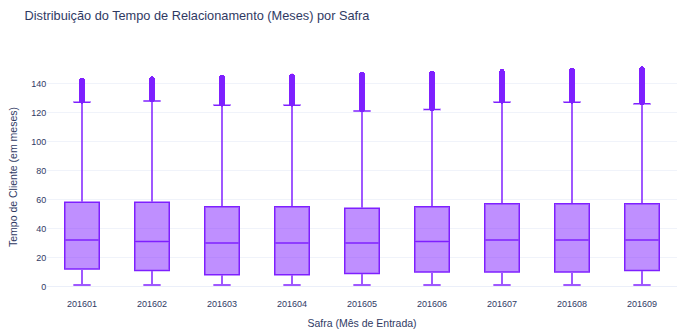